In [5]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from src.data_loader import load_stock_data

df = load_stock_data("../data/raw/AAPL.csv")

print(df.head())

        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (10468, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [8]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 1980-12-12 00:00:00
End Date: 2022-06-17 00:00:00


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df["Date"].duplicated().sum())

Duplicate rows: 0
Duplicate dates: 0


In [11]:
print(df.describe())

                             Date          Open          High           Low  \
count                       10468  10468.000000  10468.000000  10468.000000   
mean   2001-09-07 05:59:43.492548     14.757987     14.921491     14.594484   
min           1980-12-12 00:00:00      0.049665      0.049665      0.049107   
25%           1991-04-21 06:00:00      0.283482      0.289286      0.276786   
50%           2001-08-28 12:00:00      0.474107      0.482768      0.465960   
75%           2012-01-25 06:00:00     14.953303     15.057143     14.692589   
max           2022-06-17 00:00:00    182.630005    182.940002    179.119995   
std                           NaN     31.914174     32.289158     31.543959   

              Close     Adj Close        Volume  
count  10468.000000  10468.000000  1.046800e+04  
mean      14.763533     14.130431  3.308489e+08  
min        0.049107      0.038329  0.000000e+00  
25%        0.283482      0.235462  1.237768e+08  
50%        0.475446      0.392373  2.1

In [12]:
from src.validation import validate_stock_data

validate_stock_data(df)

print("Data validation passed.")

Data validation passed.


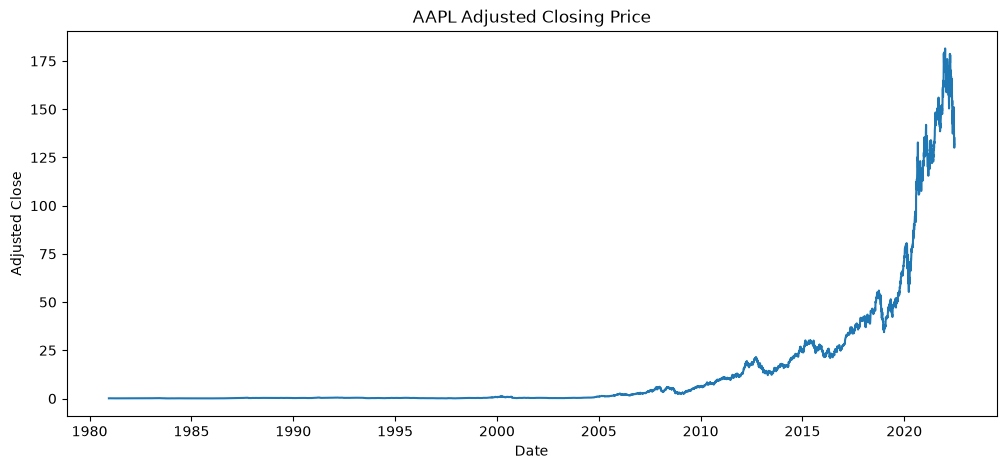

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Adj Close"]
)

plt.title("AAPL Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")

plt.show()

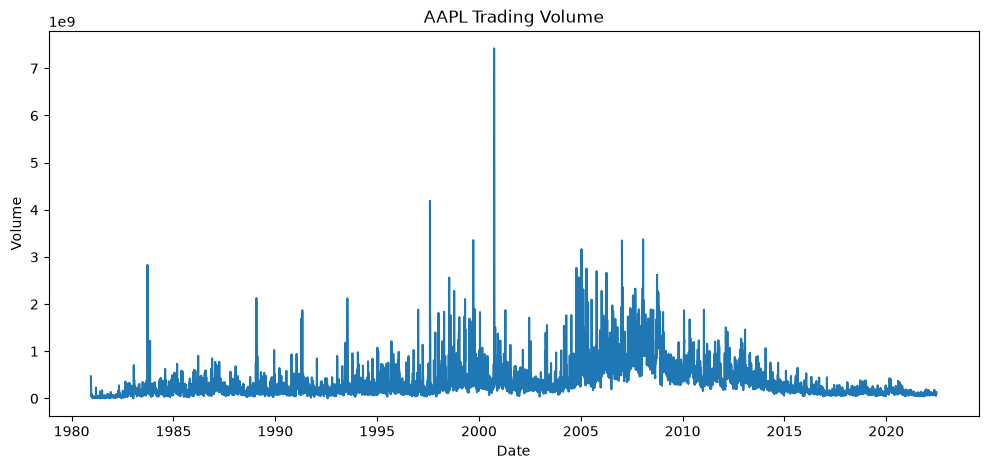

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [15]:
print(
    "High >= Low:",
    (df["High"] >= df["Low"]).all()
)

print(
    "High >= Open:",
    (df["High"] >= df["Open"]).all()
)

print(
    "High >= Close:",
    (df["High"] >= df["Close"]).all()
)

print(
    "Low <= Open:",
    (df["Low"] <= df["Open"]).all()
)

print(
    "Low <= Close:",
    (df["Low"] <= df["Close"]).all()
)

print(
    "Volume >= 0:",
    (df["Volume"] >= 0).all()
)

High >= Low: True
High >= Open: True
High >= Close: True
Low <= Open: True
Low <= Close: True
Volume >= 0: True
